In [2]:
#1
import pandas as pd
df = pd.read_excel("catalog_products.xlsx")
print('сколько всего строк и столбцов:' , df.shape)
print('какие типы данных: ',df.dtypes)
print('пропущенные значения:', df.isnull().sum())
print(df.head())

сколько всего строк и столбцов: (10000, 50)
какие типы данных:  col_1       str
col_2     int64
col_3     int64
col_4       str
col_5     int64
col_6     int64
col_7       str
col_8     int64
col_9     int64
col_10      str
col_11    int64
col_12    int64
col_13      str
col_14    int64
col_15    int64
col_16      str
col_17    int64
col_18    int64
col_19      str
col_20    int64
col_21    int64
col_22      str
col_23    int64
col_24    int64
col_25      str
col_26    int64
col_27    int64
col_28      str
col_29    int64
col_30    int64
col_31      str
col_32    int64
col_33    int64
col_34      str
col_35    int64
col_36    int64
col_37      str
col_38    int64
col_39    int64
col_40      str
col_41    int64
col_42    int64
col_43      str
col_44    int64
col_45    int64
col_46      str
col_47    int64
col_48    int64
col_49      str
col_50    int64
dtype: object
пропущенные значения: col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     0
col_8     0
col_

In [3]:
#2
for c in df.columns:
    con=pd.to_numeric(df[c], errors='coerce')
    if con.notnull().sum()>(len(df)/2):
        df[c]=con.fillna(con.mean()).astype(float)
    else:
        pass

n=df.select_dtypes(include=['number']).columns

print(df.head())

    col_1  col_2  col_3        col_4  col_5  col_6     col_7  col_8  col_9  \
0    Home  762.0  303.0  Electronics   49.0  348.0  Clothing  206.0  123.0   
1  Sports  190.0   34.0       Sports  107.0   99.0  Clothing  836.0  775.0   
2   Books  711.0    2.0         Home   93.0  876.0      Home  868.0   69.0   
3  Sports  484.0  362.0        Books  636.0  361.0      Home  897.0  111.0   
4  Sports  733.0  195.0         Home  829.0  937.0  Clothing  428.0  871.0   

        col_10  ...  col_41  col_42    col_43  col_44  col_45       col_46  \
0       Sports  ...   676.0   471.0      Home   511.0   424.0  Electronics   
1  Electronics  ...   700.0   696.0     Books   329.0   677.0  Electronics   
2        Books  ...   418.0   596.0      Home   781.0   622.0  Electronics   
3     Clothing  ...   620.0   357.0      Home   811.0   240.0     Clothing   
4         Home  ...   740.0   845.0  Clothing   272.0   143.0  Electronics   

   col_47  col_48       col_49  col_50  
0   511.0   484.0    

In [4]:
#3
import numpy as np
df['total_value']=df['col_2']*df['col_3']
df['double_stock']=df['col_4']*2
df['log_price']=np.log(df['col_2'])
print(df.head())

    col_1  col_2  col_3        col_4  col_5  col_6     col_7  col_8  col_9  \
0    Home  762.0  303.0  Electronics   49.0  348.0  Clothing  206.0  123.0   
1  Sports  190.0   34.0       Sports  107.0   99.0  Clothing  836.0  775.0   
2   Books  711.0    2.0         Home   93.0  876.0      Home  868.0   69.0   
3  Sports  484.0  362.0        Books  636.0  361.0      Home  897.0  111.0   
4  Sports  733.0  195.0         Home  829.0  937.0  Clothing  428.0  871.0   

        col_10  ...  col_44  col_45       col_46  col_47  col_48       col_49  \
0       Sports  ...   511.0   424.0  Electronics   511.0   484.0       Sports   
1  Electronics  ...   329.0   677.0  Electronics   427.0   348.0         Home   
2        Books  ...   781.0   622.0  Electronics   964.0   339.0       Sports   
3     Clothing  ...   811.0   240.0     Clothing   427.0   313.0  Electronics   
4         Home  ...   272.0   143.0  Electronics   647.0   784.0       Sports   

   col_50  total_value            double_sto

In [5]:
#4
electronics_expensive=df[(df['col_2']>500) & (df['col_7']=='Electronics')]
print(electronics_expensive.head())

          col_1  col_2  col_3        col_4  col_5  col_6        col_7  col_8  \
10         Home  605.0  250.0         Home  927.0  617.0  Electronics  506.0   
16         Home  670.0  334.0  Electronics  548.0  396.0  Electronics  994.0   
63     Clothing  926.0   35.0         Home  138.0  312.0  Electronics  197.0   
66     Clothing  716.0  813.0        Books  794.0  346.0  Electronics  448.0   
70  Electronics  937.0  526.0     Clothing  987.0  507.0  Electronics  421.0   

    col_9    col_10  ...  col_44  col_45       col_46  col_47  col_48  \
10  793.0  Clothing  ...   397.0   950.0       Sports   354.0   991.0   
16  942.0     Books  ...   277.0   250.0  Electronics   374.0   801.0   
63  966.0      Home  ...    30.0   956.0     Clothing   658.0   141.0   
66  870.0      Home  ...   756.0   593.0       Sports   840.0   627.0   
70  905.0     Books  ...   104.0    38.0     Clothing   499.0   265.0   

      col_49  col_50  total_value            double_stock  log_price  
10     Bo

In [6]:
#5
r=df.groupby('col_7').agg(
    {'col_2':['mean','max'], 'col_3':'sum'}).reset_index()
r.columns=['category','mean_price','max_price','total_quantity']
print(r)

      category  mean_price  max_price  total_quantity
0        Books  494.009027      999.0        982076.0
1     Clothing  495.738608      999.0       1008454.0
2  Electronics  505.886228      999.0       1009669.0
3         Home  511.097561      999.0        995489.0
4       Sports  509.046637      999.0       1008988.0


In [7]:
#6
df = pd.read_excel("catalog_products.xlsx")
col=[f'col_{x}' for x in range(2,12)]
df[col]=df[col].apply(pd.to_numeric,errors='coerce')
s=pd.DataFrame({
    'column': col,
    'mean':[df[c].mean() for c in col],
    'median':[df[c].median() for c in col],
    'std':[df[c].std() for c in col]
})
print(s)

   column      mean  median         std
0   col_2  503.1608   509.0  289.808030
1   col_3  500.4676   502.5  288.052132
2   col_4       NaN     NaN         NaN
3   col_5  494.9370   493.0  290.634660
4   col_6  500.0842   502.0  287.772049
5   col_7       NaN     NaN         NaN
6   col_8  500.1320   498.0  287.280092
7   col_9  494.8945   488.0  288.756643
8  col_10       NaN     NaN         NaN
9  col_11  499.8112   501.0  287.426535


In [8]:
#7
df = pd.read_excel("catalog_products.xlsx")
df['col_2']=pd.to_numeric(df['col_2'],errors='coerce')
l=(df['col_2'].mean())+(df['col_2'].std())
anomalies=df[df['col_2']>l]
print(anomalies.head())

    col_1  col_2  col_3        col_4  col_5  col_6     col_7  col_8  col_9  \
8   Books    836    647  Electronics     11    519     Books    149    924   
11  Books    812    147     Clothing    395    921      Home    168    322   
14   Home    989    254        Books    361    736     Books     13    674   
22   Home    987    562         Home    997    867    Sports    616    765   
25  Books    949    822       Sports    396    170  Clothing    660    303   

    col_10  ...  col_41  col_42    col_43  col_44  col_45  col_46  col_47  \
8   Sports  ...     784     859  Clothing     572     706  Sports     976   
11  Sports  ...     763     295  Clothing      47     310    Home     509   
14  Sports  ...     523     496  Clothing     212     706   Books     764   
22   Books  ...     571      40  Clothing     698     759    Home     431   
25  Sports  ...     149     330     Books     937     363  Sports     212   

    col_48       col_49  col_50  
8      179         Home     341  


In [9]:
#8
df = pd.read_excel("catalog_products.xlsx")
col=[f'col_{x}' for x in range(2,12)]
cor_m=df[col].corr(numeric_only=True)
print(cor_m)

           col_2     col_3     col_5     col_6     col_8     col_9    col_11
col_2   1.000000 -0.006128 -0.002368 -0.004579  0.019838 -0.008986 -0.006885
col_3  -0.006128  1.000000  0.020303  0.004545  0.014136  0.004623  0.002812
col_5  -0.002368  0.020303  1.000000  0.022725  0.015310  0.013237 -0.000047
col_6  -0.004579  0.004545  0.022725  1.000000 -0.005012  0.002743 -0.019907
col_8   0.019838  0.014136  0.015310 -0.005012  1.000000 -0.008199  0.002730
col_9  -0.008986  0.004623  0.013237  0.002743 -0.008199  1.000000  0.017898
col_11 -0.006885  0.002812 -0.000047 -0.019907  0.002730  0.017898  1.000000


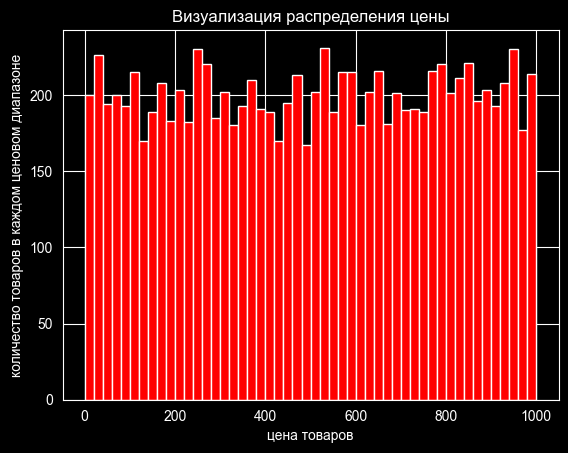

In [10]:
#9
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.hist(df['col_2'].dropna(),color='red', bins=50)
ax.set_title('Визуализация распределения цены')
ax.set_xlabel('цена товаров')
ax.set_ylabel('количество товаров в каждом ценовом диапазоне')
ax.grid(True)
plt.show()

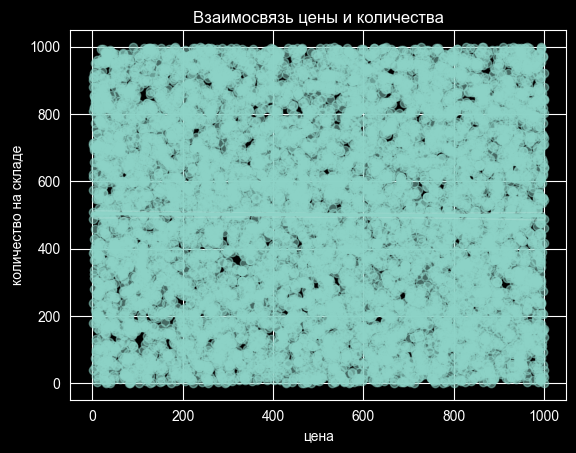

In [11]:
#10
import seaborn as sns
df = pd.read_excel("catalog_products.xlsx")
fig, ax = plt.subplots()
data=df[['col_2','col_3']].dropna()
sns.regplot(
    x='col_2',
    y='col_3',
    data=data,
    ax=ax,
    scatter_kws={'alpha':0.5}
)
ax.set_title('Взаимосвязь цены и количества')
ax.set_xlabel('цена')
ax.set_ylabel('количество на складе')
ax.grid(True)
plt.show()

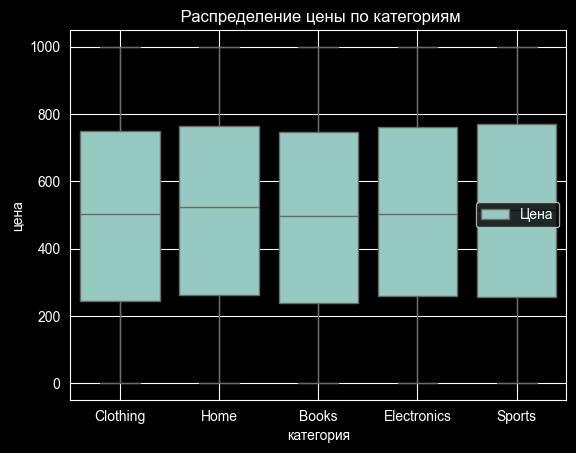

In [12]:
#11
df = pd.read_excel("catalog_products.xlsx")
fig, ax = plt.subplots()
data=df[['col_7','col_2']].dropna()
sns.boxplot(
    x='col_7',
    y='col_2',
    data=data,
    ax=ax
)
ax.set_title(' Распределение цены по категориям')
ax.set_xlabel('категория')
ax.set_ylabel('цена')
ax.legend(['Цена'])
ax.grid(True)
plt.show()

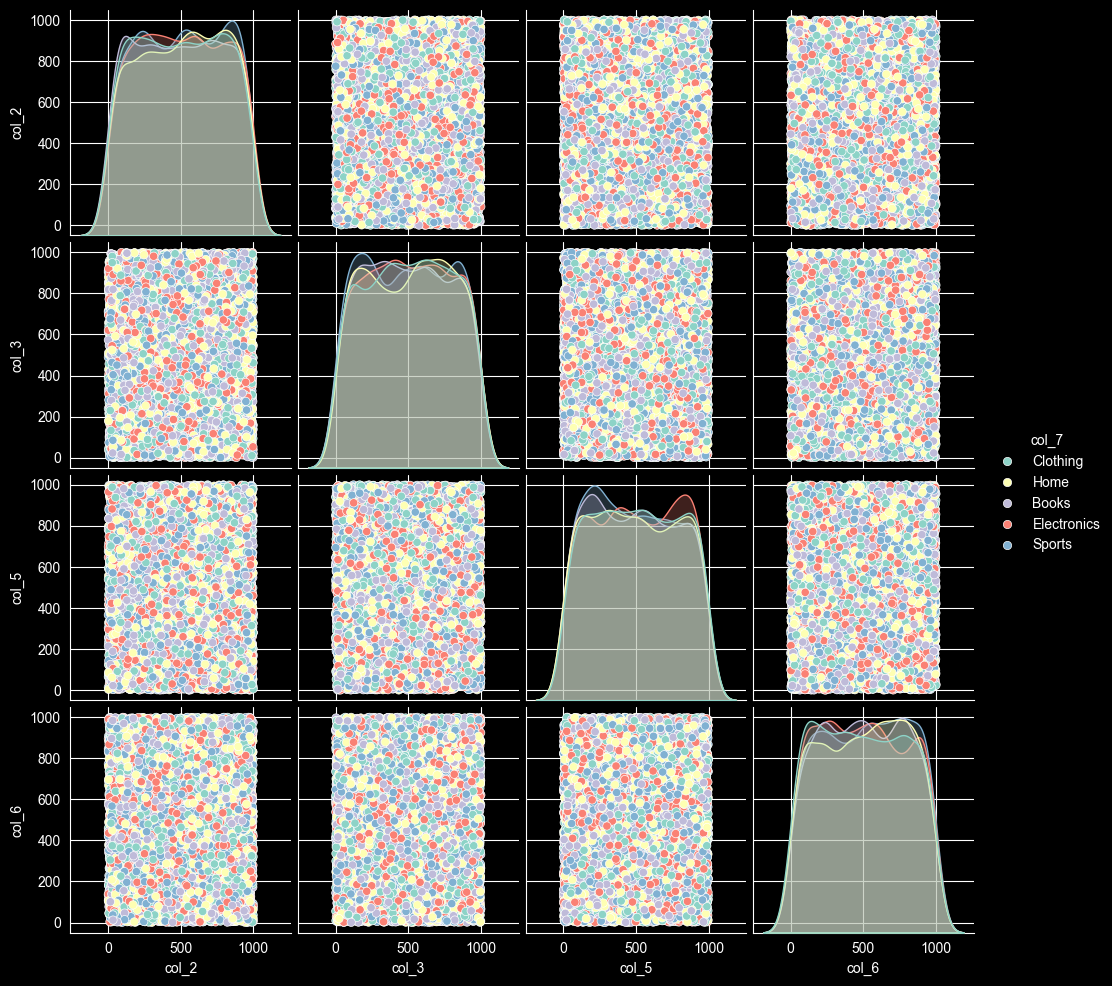

In [13]:
#12
df = pd.read_excel("catalog_products.xlsx")
col=['col_2','col_3','col_4','col_5','col_6','col_7']
fig, ax = plt.subplots()
sns.pairplot(df[col],hue='col_7')
plt.show()

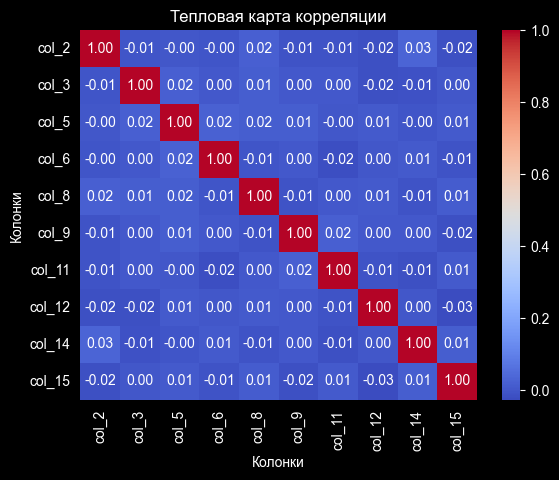

In [14]:
#13
df = pd.read_excel("catalog_products.xlsx")
col=['col_2','col_3','col_5','col_6','col_8','col_9','col_11','col_12','col_14','col_15']
c=df[col].corr()
fig, ax = plt.subplots()
sns.heatmap(c,annot=True,cmap='coolwarm',fmt='.2f',ax=ax)
ax.set_title('Тепловая карта корреляции')
ax.set_xlabel('Колонки')
ax.set_ylabel('Колонки')
plt.show()

In [15]:
#14
df['total_value']=df['col_2']*df['col_3']
df['double_stock']=df['col_4']*2
df['log_price']=np.log(df['col_2'])
result = df[[
    "col_1", "col_2", "col_3", "col_4", "col_5",
    "col_6", "col_7", "total_value", "double_stock", "log_price"]]

result.to_excel("catalog_analysis.xlsx", index=False)

print(df.head())

    col_1  col_2  col_3        col_4  col_5  col_6     col_7  col_8  col_9  \
0    Home    762    303  Electronics     49    348  Clothing    206    123   
1  Sports    190     34       Sports    107     99  Clothing    836    775   
2   Books    711      2         Home     93    876      Home    868     69   
3  Sports    484    362        Books    636    361      Home    897    111   
4  Sports    733    195         Home    829    937  Clothing    428    871   

        col_10  ...  col_44  col_45       col_46  col_47  col_48       col_49  \
0       Sports  ...     511     424  Electronics     511     484       Sports   
1  Electronics  ...     329     677  Electronics     427     348         Home   
2        Books  ...     781     622  Electronics     964     339       Sports   
3     Clothing  ...     811     240     Clothing     427     313  Electronics   
4         Home  ...     272     143  Electronics     647     784       Sports   

   col_50  total_value            double_sto

In [16]:
#15
category_summary=df.groupby('col_7').agg(
    count=('col_7','count'),
    mean_price=('col_2','mean'),
    total_quantity=('col_3','sum'),
    mean_log_price=('log_price','mean')
).reset_index()
category_summary=category_summary.rename(columns={'col_7':'category'})
print(category_summary.head())

      category  count  mean_price  total_quantity  mean_log_price
0        Books   1994  494.009027          982076        5.879360
1     Clothing   1997  495.738608         1008454        5.892562
2  Electronics   2004  505.886228         1009669        5.933533
3         Home   1968  511.097561          995489        5.935257
4       Sports   2037  509.046637         1008988        5.939490


In [17]:
#16
i=df.groupby('col_7')['col_2'].idxmax()
most_expensive=df.loc[i,['col_1','col_2','col_7']]
print(most_expensive)

         col_1  col_2        col_7
1117    Sports    999        Books
1019      Home    999     Clothing
1478    Sports    999  Electronics
3101  Clothing    999         Home
2890    Sports    999       Sports


In [18]:
#17
top=df.sort_values(by='total_value',ascending=False)
print(top[['col_1','col_2','col_3','total_value']].head(10))

            col_1  col_2  col_3  total_value
3833        Books    994    999       993006
4494       Sports    993    997       990021
9335     Clothing    994    992       986048
6431         Home    988    981       969228
3725  Electronics    997    971       968087
3389  Electronics    986    979       965294
3026  Electronics    997    968       965096
9202       Sports    966    996       962136
1380  Electronics    963    998       961074
3956     Clothing    982    975       957450


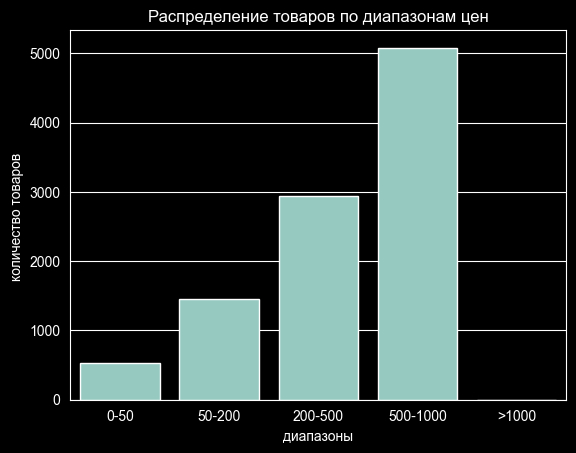

In [19]:
#18
b=[0,50,200,500,1000,float('inf')]
l=['0-50','50-200','200-500','500-1000','>1000']
df['price_range']=pd.cut(df['col_2'],bins=b,labels=l,include_lowest=True)
price_c=df['price_range'].value_counts().sort_index().reset_index()
price_c.columns=['price_range','count']
fig, ax = plt.subplots()
sns.barplot(x='price_range',y='count',data=price_c, ax=ax)
ax.set_title('Распределение товаров по диапазонам цен')
ax.set_xlabel('диапазоны')
ax.set_ylabel('количество товаров ')
plt.show()

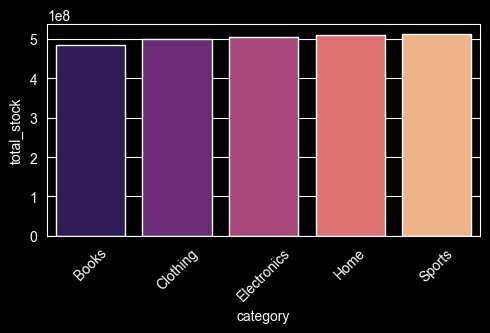

In [20]:
#19
df['stock_value']=df['col_2']*df['col_3']
category_value=df.groupby('col_7').agg(
    total_stock=('stock_value','sum')
).reset_index()
category_value=category_value.rename(columns={'col_7':'category'})
max_c=category_value.sort_values(by='total_stock',ascending=False)




plt.figure(figsize=(5,3))
sns.barplot(x='category',y='total_stock',data=category_value,palette='magma')
ax.set_title('Анализ категории с наибольшей суммарной стоимостью')
ax.set_xlabel('категорий')
ax.set_ylabel('суммарной стоимостью ')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

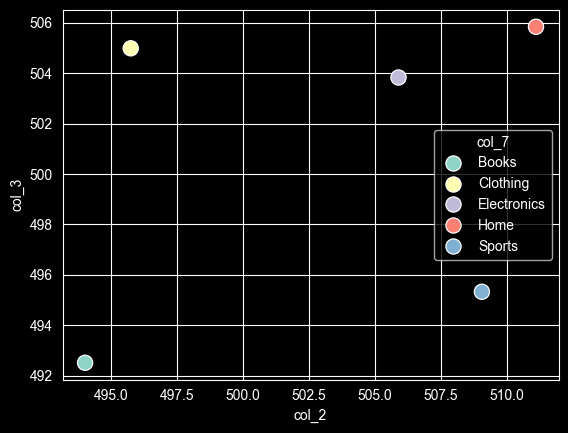

In [21]:
#20
category_stat=df.groupby('col_7').agg({
    'col_2':'mean','col_3':'mean'
}
).reset_index()
fig, ax = plt.subplots()
sns.scatterplot(x='col_2',y='col_3',data=category_stat, hue='col_7',ax=ax,s=120)

plt.show()

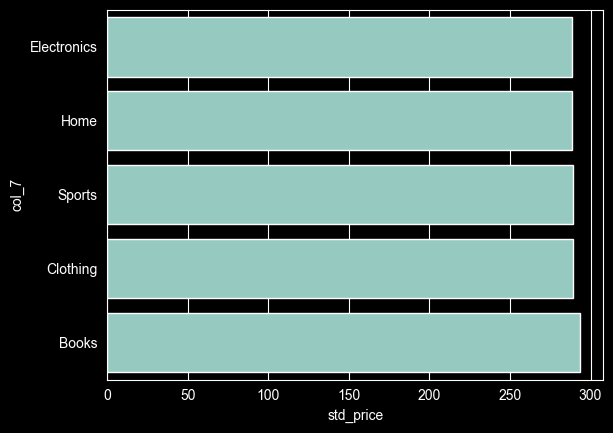

In [22]:
#21
price_s=df.groupby('col_7').agg(std_price=('col_2','std')).reset_index()
price_s=price_s.sort_values(by='std_price',ascending=True)
fig, ax = plt.subplots()

sns.barplot(x='std_price',y='col_7',data=price_s,ax=ax)
plt.show()

In [23]:
#22
re=df[df['col_3']==0][['col_1','col_7','col_2']]
print(re.head(10))

Empty DataFrame
Columns: [col_1, col_7, col_2]
Index: []


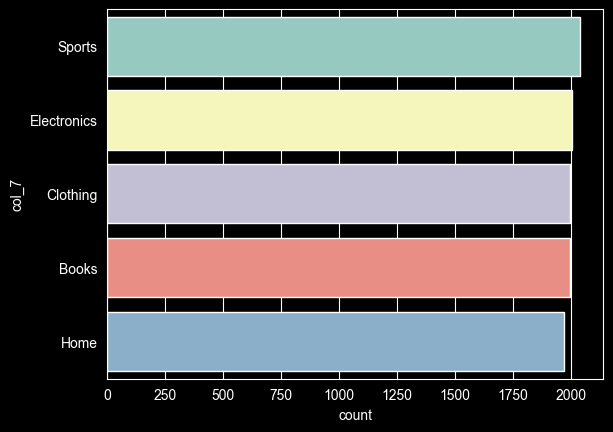

In [24]:
#23
c=df.groupby('col_7').size().reset_index(name='count')
top=c.sort_values(by='count',ascending=False).head()
fig, ax = plt.subplots()
sns.barplot(data=top,x='count',y='col_7',hue='col_7')
plt.show()

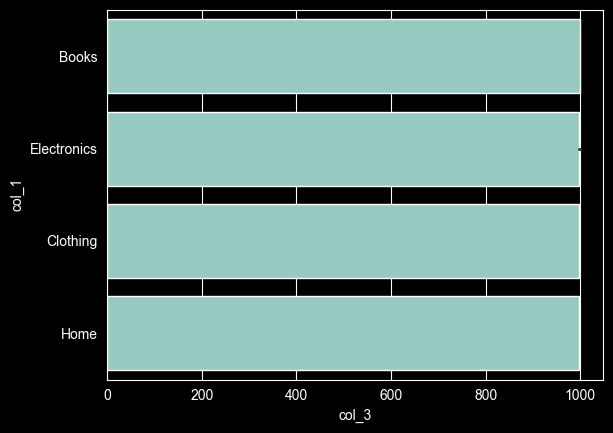

In [25]:
#24
top_s=df.sort_values(by='col_3',ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=top_s,x='col_3',y='col_1',ax=ax)
plt.show()

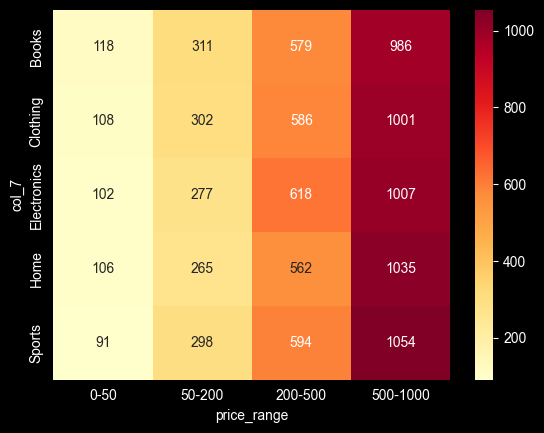

In [26]:
#25
df['price_range']=pd.cut(df['col_2'],bins=b,labels=l,include_lowest=True)
heat_data=pd.crosstab(df['col_7'],df['price_range'])
fig, ax = plt.subplots()
sns.heatmap(heat_data,annot=True,fmt='d',cmap='YlOrRd',ax=ax)
plt.show()

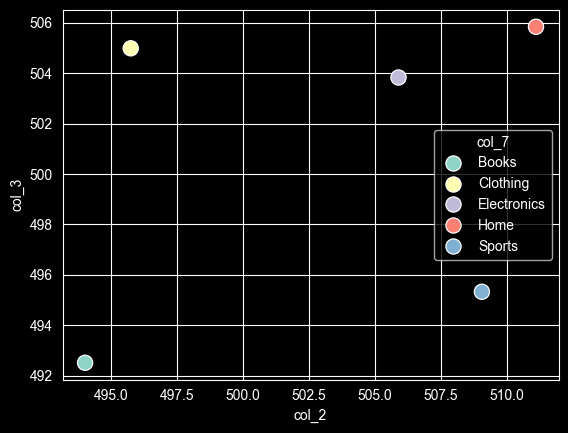

In [27]:
#36
category_stat=df.groupby('col_7').agg({
    'col_2':'mean','col_3':'mean'
}
).reset_index()
fig, ax = plt.subplots()
sns.scatterplot(x='col_2',y='col_3',data=category_stat, hue='col_7',ax=ax,s=120)

plt.show()

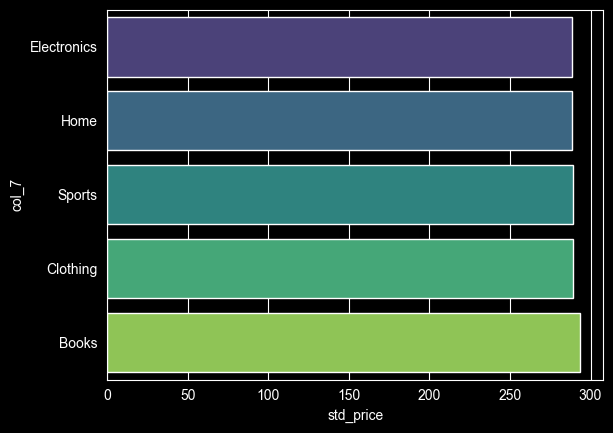

In [28]:
#37
price_s=df.groupby('col_7').agg(std_price=('col_2','std')).reset_index()
price_s=price_s.sort_values(by='std_price',ascending=True)
fig, ax = plt.subplots()

sns.barplot(x='std_price',y='col_7',data=price_s,ax=ax,palette='viridis')
plt.show()

In [29]:
#38
re=df[df['col_3']==0][['col_1','col_7','col_2']]
print(re.head(10))

Empty DataFrame
Columns: [col_1, col_7, col_2]
Index: []


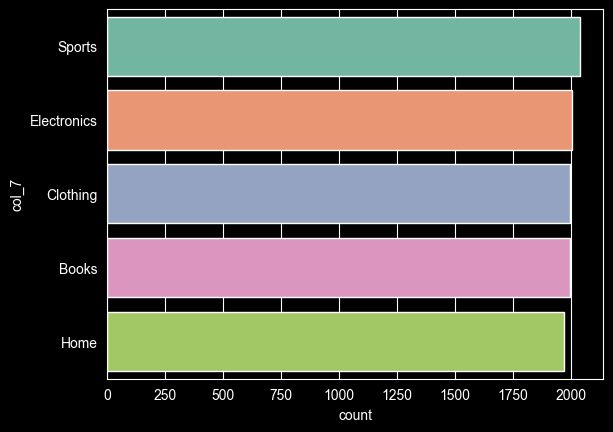

In [30]:
#39
c=df.groupby('col_7').size().reset_index(name='count')
top=c.sort_values(by='count',ascending=False).head()
fig, ax = plt.subplots()
sns.barplot(data=top,x='count',y='col_7',hue='col_7',palette='Set2')
plt.show()

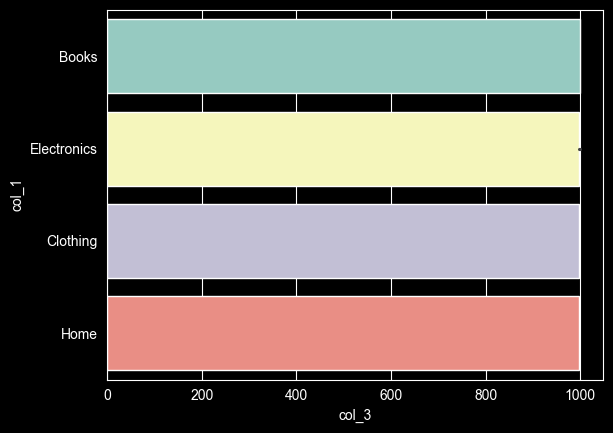

In [31]:
#40
top_s=df.sort_values(by='col_3',ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=top_s,x='col_3',y='col_1',hue='col_1',ax=ax)
plt.show()

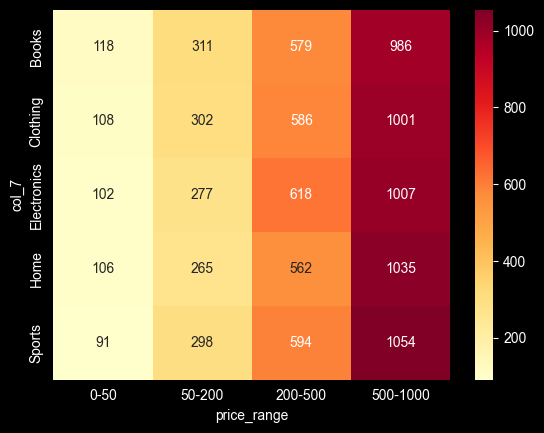

In [32]:
#41
df['price_range']=pd.cut(df['col_2'],bins=b,labels=l,include_lowest=True)
heat_data=pd.crosstab(df['col_7'],df['price_range'])
fig, ax = plt.subplots()
sns.heatmap(heat_data,annot=True,fmt='d',cmap='YlOrRd',ax=ax)
plt.show()

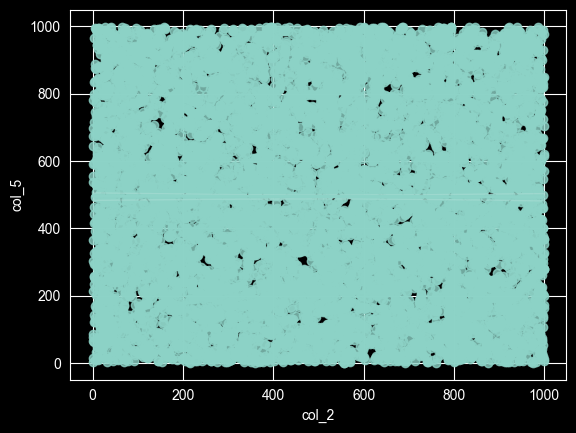

In [33]:
#42
fig, ax = plt.subplots()
data=df[['col_2','col_5']].dropna()
sns.regplot(
    x='col_2',
    y='col_5',
    data=data,
    ax=ax
)
ax.grid(True)
plt.show()

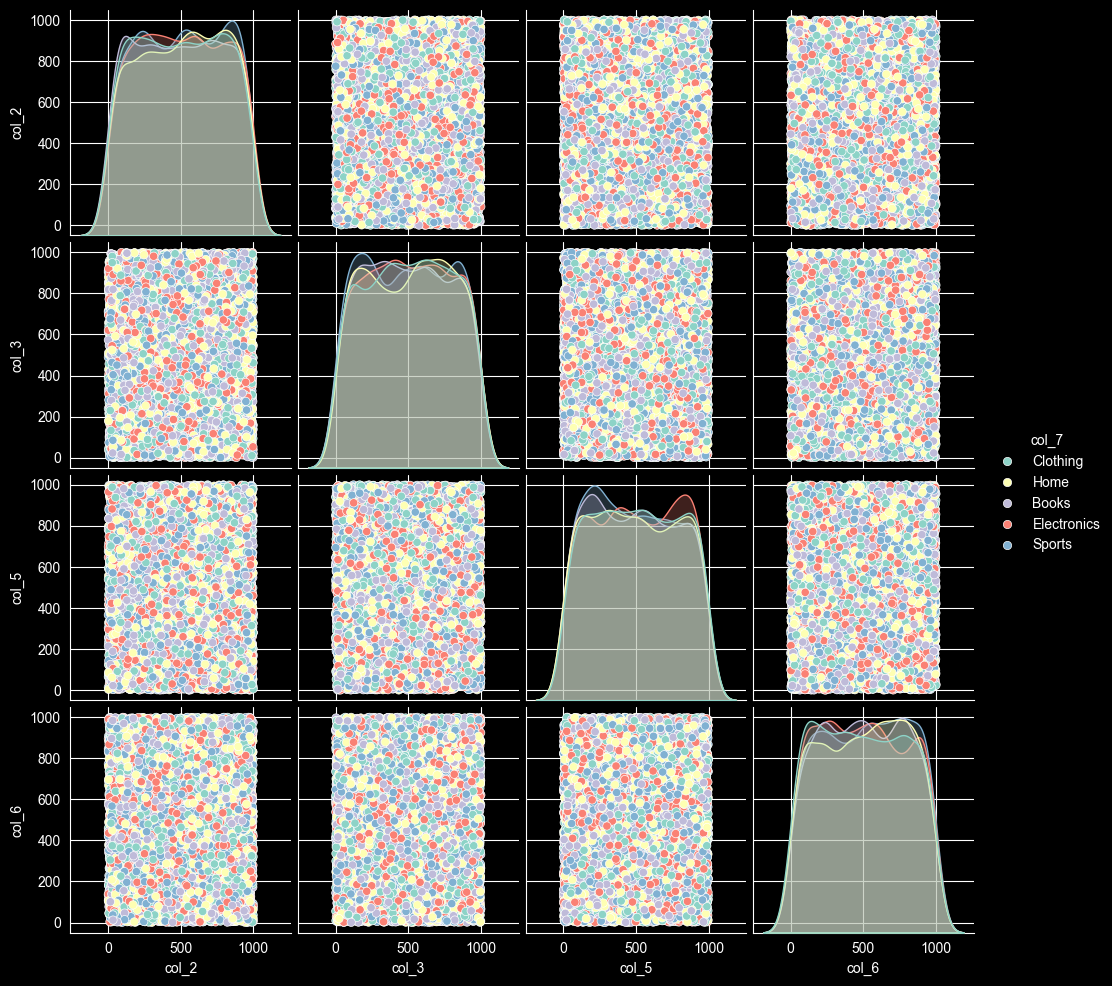

In [34]:
#43
col=['col_2','col_3','col_4','col_5','col_6','col_7']
fig, ax = plt.subplots()

sns.pairplot(df[col],hue='col_7')
plt.show()

In [35]:
#44
mean=df['col_2'].mean()
std=df['col_2'].std()
s_mean=df['col_3'].mean()
s_std=df['col_3'].std()
extreme_items=df[
    (df['col_2']>mean+3*std)|
    (df['col_3']>s_mean+3*s_std)]
print((extreme_items))

Empty DataFrame
Columns: [col_1, col_2, col_3, col_4, col_5, col_6, col_7, col_8, col_9, col_10, col_11, col_12, col_13, col_14, col_15, col_16, col_17, col_18, col_19, col_20, col_21, col_22, col_23, col_24, col_25, col_26, col_27, col_28, col_29, col_30, col_31, col_32, col_33, col_34, col_35, col_36, col_37, col_38, col_39, col_40, col_41, col_42, col_43, col_44, col_45, col_46, col_47, col_48, col_49, col_50, total_value, double_stock, log_price, price_range, stock_value]
Index: []

[0 rows x 55 columns]


In [38]:
#45
df['total_value']=df['col_2']*df['col_3']
category_summary=df.groupby('col_7').agg(
    count=('col_7','count'),
    mean_price=('col_2','mean'),
    total_quantity=('col_3','sum'),
).reset_index()
category_summary=category_summary.rename(columns={'col_7':'category'})
top_s=df.sort_values(by='col_3',ascending=False).head(10)
top_v=df.sort_values(by='total_value',ascending=False).head(10)
with pd.ExcelWriter('catalog_final_report.xlsx',engine='openpyxl') as f:
    category_summary.to_excel(f,sheet_name='Processed_Data',index=False)
    top_s.to_excel(f,sheet_name='топ-10 товаров по запасу',index=False)
    top_v.to_excel(f,sheet_name='топ-10 товаров по стоимости',index=False)